# CNMFe — Realistic-use demo

This notebook shows the workflow you'd use with real miniscope data:

1. Start with an AVI recording on disk
2. Convert it to a time-chunked zarr store (one-time step)
3. Open the zarr **lazily** — no data is loaded into RAM until needed
4. Run the full pipeline: motion correction → background → CNMF-E extraction
5. Inspect results

**Prerequisites:** run these two scripts from the project root first:
```bash
python generate_demo_movies.py   # creates demo_movies/*.avi
python convert_to_zarr.py        # creates demo_movies/*.zarr
```

Then change `MOVIE_NAME` in the next cell to try different movies:
- `simple_small` — 64×64, 300 frames, 6 neurons, no motion (fast sanity check)
- `simple_medium` — 128×128, 1000 frames, 12 neurons
- `realistic_small` — 64×64, 300 frames, 8 neurons + artefacts + drift
- `realistic_medium` — 128×128, 600 frames, 15 neurons (recommended)
- `realistic_large` — 256×256, 1000 frames, 25 neurons (stress test)

In [1]:
import os

from cnmfe.io import open_zarr
import numpy as np
from pathlib import Path

# ── Movie source ──────────────────────────────────────────────────────────────
# USE_REAL_VIDEO = True  → runs on real_vids/movie.zarr (no ground truth).
# USE_REAL_VIDEO = False → uses a synthetic demo movie (run the two scripts first).
USE_REAL_VIDEO = True

if USE_REAL_VIDEO:
    MOVIE_NAME = 'real_movie'
    zarr_path = Path("../real_vids") / "movie.zarr"
    has_ground_truth = False
    true_shifts      = None
else:
    MOVIE_NAME = "realistic_small"   # ← change to try different movies
    zarr_path  = Path("../demo_movies") / f"{MOVIE_NAME}.zarr"
    meta_path  = Path("../demo_movies") / f"{MOVIE_NAME}_meta.npz"

z = open_zarr(zarr_path)   # lazy — nothing is read from disk yet
T, H, W = z.shape
zarr_mb = sum(f.stat().st_size for f in zarr_path.rglob("*") if f.is_file()) / 1e6
print(f"Movie  : {z.shape}  chunks={z.chunks}  dtype={z.dtype}")
print(f"Zarr   : {zarr_mb:.1f} MB")

if not USE_REAL_VIDEO:
    meta = np.load(meta_path)
    A_true     = meta["A_true"]          # (H*W, K_true)
    C_true     = meta["C_true"]          # (K_true, T)
    K_true     = C_true.shape[0]
    has_motion = "motion_shifts" in meta.files
    true_shifts = meta["motion_shifts"] if has_motion else None   # (T, 2)
    has_ground_truth = True
    print(f"True neurons: {K_true}   simulated motion: {has_motion}")
else:
    print("Real recording — no ground truth metadata available.")

Movie  : (1000, 600, 600)  chunks=(100, 600, 600)  dtype=uint8
Zarr   : 257.5 MB
Real recording — no ground truth metadata available.


In [2]:
import os
os.curdir

'.'

## 1. Preview — a few frames from the recording

Only the requested chunks are loaded from disk. The rest of the movie stays on disk.

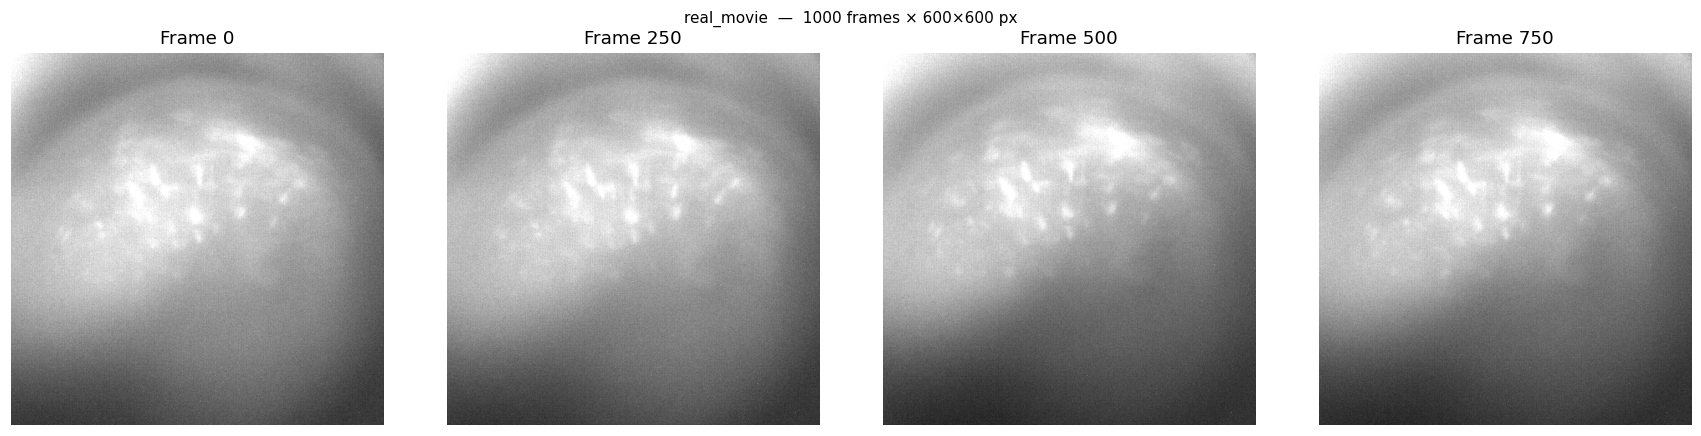

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

frame_indices = [0, T // 4, T // 2, 3 * T // 4]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, t in zip(axes, frame_indices):
    frame = z[t]   # loads only the chunk containing frame t
    vmax  = float(np.percentile(frame, 99))
    ax.imshow(frame, cmap="gray", vmin=0, vmax=vmax)
    ax.set_title(f"Frame {t}")
    ax.axis("off")
plt.suptitle(f"{MOVIE_NAME}  —  {T} frames × {H}×{W} px", fontsize=10)
plt.tight_layout()
plt.show()

## 1b. Parameter estimation (no ground truth needed)

Before running the full pipeline, inspect the movie to choose `sigma`, `min_corr`, and `min_pnr`.

**Workflow:**
1. Look at the temporal-std image → estimate neuron diameter → set `sigma ≈ diameter / 4`
2. Compute CORR and PNR maps at that sigma
3. Read the threshold sweep table → pick `(min_corr, min_pnr)` whose peak count is close to the expected neuron count

In [4]:

# ── (A) Sigma estimation ─────────────────────────────────────────────────────
# Sample ≤1000 frames evenly — loads only the needed zarr chunks.
stride = max(1, T // 1000)
t_idx  = np.arange(0, T, stride)
# sample = np.stack([z[int(t)] for t in t_idx])   # (T', H, W)


In [5]:
sample = np.asarray(z[t_idx])   # zarr fancy-index → numpy (T', H, W) in one bulk read
sample.shape

(1000, 600, 600)

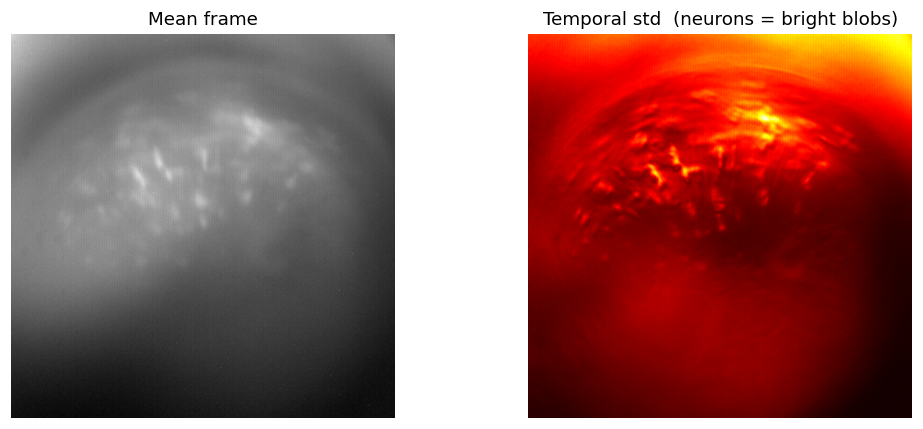

Measure a neuron blob diameter (px) in the std image.
sigma ≈ diameter / 4   (neurons are approximately 4σ wide)
Using 334 frames for CORR/PNR (subsampled 3×)...


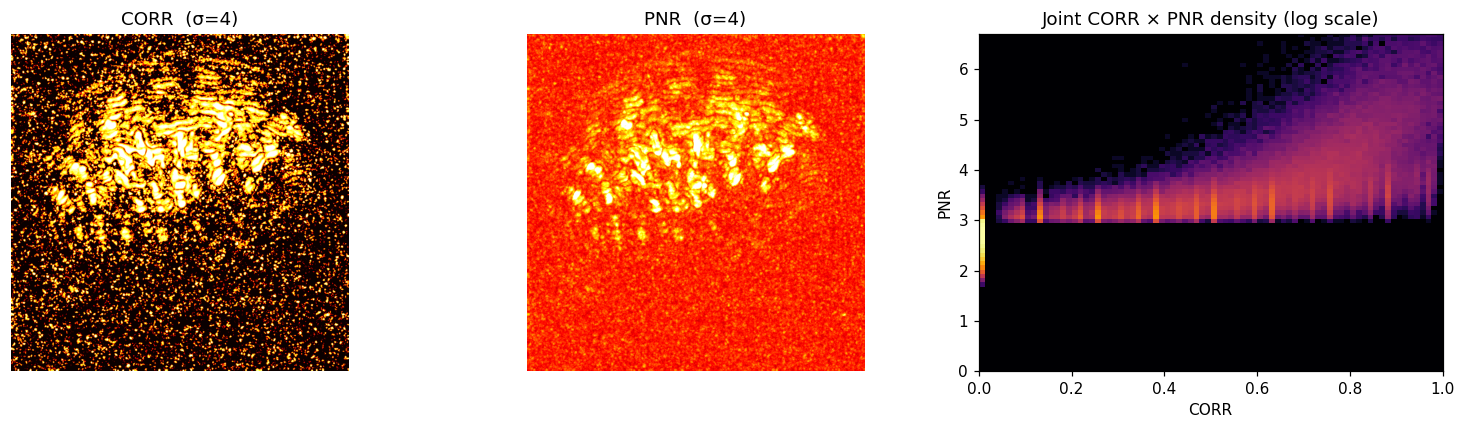

              pnr≥ 6  pnr≥ 8  pnr≥10  pnr≥12  pnr≥15  pnr≥20
────────────────────────────────────────────────────────────
corr≥0.75       121      41      19       6       0       0
corr≥0.80       121      41      19       6       0       0
corr≥0.85       119      41      19       6       0       0
corr≥0.90       112      41      19       6       0       0
corr≥0.95       103      41      19       6       0       0

FOV: 600×600 px.  Target: peak count ≈ expected neuron count.


In [6]:
from cnmfe.preprocess import correlation_pnr
from scipy.ndimage import maximum_filter
mean_img = sample.mean(axis=0)
std_img  = sample.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(mean_img, cmap="gray")
axes[0].set_title("Mean frame")
axes[0].axis("off")
axes[1].imshow(std_img, cmap="hot")
axes[1].set_title("Temporal std  (neurons = bright blobs)")
axes[1].axis("off")
plt.tight_layout()
plt.show()
print("Measure a neuron blob diameter (px) in the std image.")
print("sigma ≈ diameter / 4   (neurons are approximately 4σ wide)")

# ── (B) CORR and PNR maps ────────────────────────────────────────────────────
sigma_try = 4    # ← update based on std image above

# CORR/PNR maps stabilise at ~300 frames — subsample for speed.
# n_jobs=-1 parallelises the per-frame PSF convolution across all CPUs.
cn_stride  = max(1, len(sample) // 300)
sample_cn  = sample[::cn_stride]
print(f"Using {len(sample_cn)} frames for CORR/PNR (subsampled {cn_stride}×)...")
cn, pnr = correlation_pnr(sample_cn, sigma=sigma_try, n_jobs=-1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(cn, cmap="hot", vmin=0, vmax=1)
axes[0].set_title(f"CORR  (σ={sigma_try})")
axes[0].axis("off")
pnr_clip = float(np.percentile(pnr[np.isfinite(pnr)], 99))
axes[1].imshow(pnr, cmap="hot", vmin=0, vmax=pnr_clip)
axes[1].set_title(f"PNR  (σ={sigma_try})")
axes[1].axis("off")
h, xe, ye = np.histogram2d(cn.ravel(), pnr.ravel(), bins=80,
                            range=[[0, 1], [0, pnr_clip]])
axes[2].imshow(np.log1p(h.T), origin="lower", aspect="auto",
               extent=[xe[0], xe[-1], ye[0], ye[-1]], cmap="inferno")
axes[2].set_xlabel("CORR")
axes[2].set_ylabel("PNR")
axes[2].set_title("Joint CORR × PNR density (log scale)")
plt.tight_layout()
plt.show()

# ── (C) Threshold sweep → seed count ────────────────────────────────────────
# Counts local maxima in the CORR×PNR score map above each threshold pair.
# This is the same strategy the greedy initialiser uses.
# Choose thresholds where the count is close to (or a bit above) expected neurons.
score        = cn * pnr
filt_size    = max(3, int(2 * sigma_try + 1))
is_local_max = maximum_filter(score, size=filt_size) == score

corr_vals = [0.75, 0.80, 0.85, 0.90, 0.95]
pnr_vals  = [6, 8, 10, 12, 15, 20]

hdr = f"{'':>12}" + "".join(f"  pnr≥{p:2d}" for p in pnr_vals)
print(hdr)
print("─" * len(hdr))
for cv in corr_vals:
    row = f"corr≥{cv:.2f}  "
    for pv in pnr_vals:
        n = int(((cn >= cv) & (pnr >= pv) & is_local_max).sum())
        row += f"  {n:6d}"
    print(row)

print(f"\nFOV: {H}×{W} px.  Target: peak count ≈ expected neuron count.")

## 1c. Auto-detect neuron-dense ROI for motion correction

Motion correction estimates shifts by cross-correlating each frame with a template.
Computing shifts on a **neuron-dense sub-region** gives a cleaner signal when the FOV
contains large dim areas, vasculature, or featureless edges that can bias the peak.
The shift is still applied to the full frame — only estimation uses the crop.

Inspect the green box below. If it misses most neurons, override `roi` manually.

In [7]:
from cnmfe.motion_correction import select_roi

roi = select_roi(z, frac_h=0.5, frac_w=0.5, n_frames=800, border_margin=40, hp_sigma=25.0)
print(f"Selected ROI: y={roi[0].start}:{roi[0].stop}  x={roi[1].start}:{roi[1].stop}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(mean_img, cmap="gray")
axes[0].add_patch(plt.Rectangle(
    (roi[1].start, roi[0].start),
    roi[1].stop - roi[1].start, roi[0].stop - roi[0].start,
    edgecolor="lime", facecolor="none", lw=2,
))
axes[0].set_title("Mean frame + selected ROI (green box)")
axes[0].axis("off")
axes[1].imshow(mean_img[roi], cmap="gray")
axes[1].set_title("ROI crop")
axes[1].axis("off")
plt.tight_layout()
plt.show()

# Override if the auto-detection looks wrong:
# roi = (slice(100, 400), slice(150, 450))

TypeError: object of type 'Array' has no len()

In [8]:
movie

NameError: name 'movie' is not defined

In [8]:
# from cnmfe.preprocess import correlation_pnr
# from scipy.ndimage import maximum_filter
#
# # ── (A) Sigma estimation ─────────────────────────────────────────────────────
# # Sample ≤1000 frames evenly — loads only the needed zarr chunks.
# stride = max(1, T // 1000)
# t_idx  = np.arange(0, T, stride)
# sample = np.stack([z[int(t)] for t in t_idx])   # (T', H, W)
#
# mean_img = sample.mean(axis=0)
# std_img  = sample.std(axis=0)
#
# fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# axes[0].imshow(mean_img, cmap="gray")
# axes[0].set_title("Mean frame")
# axes[0].axis("off")
# axes[1].imshow(std_img, cmap="hot")
# axes[1].set_title("Temporal std  (neurons = bright blobs)")
# axes[1].axis("off")
# plt.tight_layout()
# plt.show()
# print("Measure a neuron blob diameter (px) in the std image.")
# print("sigma ≈ diameter / 4   (neurons are approximately 4σ wide)")
#
# # ── (B) CORR and PNR maps ────────────────────────────────────────────────────
# sigma_try = 2     # ← update based on std image above
#
# cn, pnr = correlation_pnr(sample, sigma=sigma_try)
#
# fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# axes[0].imshow(cn, cmap="hot", vmin=0, vmax=1)
# axes[0].set_title(f"CORR  (σ={sigma_try})")
# axes[0].axis("off")
# pnr_clip = float(np.percentile(pnr[np.isfinite(pnr)], 99))
# axes[1].imshow(pnr, cmap="hot", vmin=0, vmax=pnr_clip)
# axes[1].set_title(f"PNR  (σ={sigma_try})")
# axes[1].axis("off")
# h, xe, ye = np.histogram2d(cn.ravel(), pnr.ravel(), bins=80,
#                             range=[[0, 1], [0, pnr_clip]])
# axes[2].imshow(np.log1p(h.T), origin="lower", aspect="auto",
#                extent=[xe[0], xe[-1], ye[0], ye[-1]], cmap="inferno")
# axes[2].set_xlabel("CORR")
# axes[2].set_ylabel("PNR")
# axes[2].set_title("Joint CORR × PNR density (log scale)")
# plt.tight_layout()
# plt.show()
#
# # ── (C) Threshold sweep → seed count ────────────────────────────────────────
# # Counts local maxima in the CORR×PNR score map above each threshold pair.
# # This is the same strategy the greedy initialiser uses.
# # Choose thresholds where the count is close to (or a bit above) expected neurons.
# score        = cn * pnr
# filt_size    = max(3, int(2 * sigma_try + 1))
# is_local_max = maximum_filter(score, size=filt_size) == score
#
# corr_vals = [0.75, 0.80, 0.85, 0.90, 0.95]
# pnr_vals  = [6, 8, 10, 12, 15, 20]
#
# hdr = f"{'':>12}" + "".join(f"  pnr≥{p:2d}" for p in pnr_vals)
# print(hdr)
# print("─" * len(hdr))
# for cv in corr_vals:
#     row = f"corr≥{cv:.2f}  "
#     for pv in pnr_vals:
#         n = int(((cn >= cv) & (pnr >= pv) & is_local_max).sum())
#         row += f"  {n:6d}"
#     print(row)
#
# print(f"\nFOV: {H}×{W} px.  Target: peak count ≈ expected neuron count.")

## 2. Motion correction

Runs rigid FFT-based motion correction and saves the corrected movie to `demo_output/mc.zarr`.

`mc_gSig_filt` applies a centered Gaussian high-pass to frames before shift estimation —
strongly recommended for 1p miniscope data where the slow fluorescence background biases
the cross-correlation peak. Set it to approximately the neuron `sigma`.

The corrected movie is returned as a float32 numpy array (`mc_arr`) and kept in memory
for the quality-check cells and the extraction step below.

In [ ]:
import time
from cnmfe.pipeline import CNMFe, CNMFeParams

params = CNMFeParams(
    sigma=4,
    min_corr=0.8,
    min_pnr=8.0,
    n_iter_main=2,
    n_iter_temporal=2,
    mc_n_iter=2,
    mc_gSig_filt=9.0,        # 1p high-pass sigma for shift estimation (≈ neuron sigma)
    mc_roi=roi,               # neuron-dense sub-region for shift estimation (from cell 1c)
    spatial_max_thr=0.1,
    merge_thr_corr=0.85,
    merge_thr_overlap=0.5,
    global_ar=False,
    n_jobs=-1,
    sample_frames=1000,
    skip_first_deconv=True,
    bg_tsub=5,
)

demo_out = Path("demo_output")
demo_out.mkdir(exist_ok=True)

model  = CNMFe(params)
t0     = time.time()
# mc_arr is a zarr handle — the corrected movie lives on disk, not in RAM.
mc_arr = model.fit_mc(z, output_dir=demo_out)
T_mc, H_mc, W_mc = mc_arr.shape
print(f"Motion correction done in {time.time() - t0:.1f} s")
print(f"MC zarr: {mc_arr.shape}  dtype={mc_arr.dtype}")
dy_range = (float(model.shifts[:, 0].min()), float(model.shifts[:, 0].max()))
dx_range = (float(model.shifts[:, 1].min()), float(model.shifts[:, 1].max()))
print(f"Shift range:  dy=[{dy_range[0]:.1f}, {dy_range[1]:.1f}]  "
      f"dx=[{dx_range[0]:.1f}, {dx_range[1]:.1f}] px")
print(f"MC zarr saved to: {demo_out / 'mc.zarr'}")

## 2b. Motion correction quality

Three checks:

1. **Shift trajectory** — the (dy, dx) shift applied to each frame.
   A smooth, bounded curve is healthy. Jumps > ~10 px suggest abrupt movements or tracking failures.
   For synthetic movies with known drift, `−model.shifts` should closely match the simulated drift.

2. **Frame at peak shift** — the raw frame vs motion-corrected frame for the most-shifted
   time point, plus a difference image. The difference should look like a shifted copy of the
   neuronal field (a border/ring pattern) rather than random noise.

3. **Mean frame before vs after** — temporal mean of the raw subsampled movie vs the full MC movie.
   Cell bodies should appear tighter after correction; background should be more uniform.

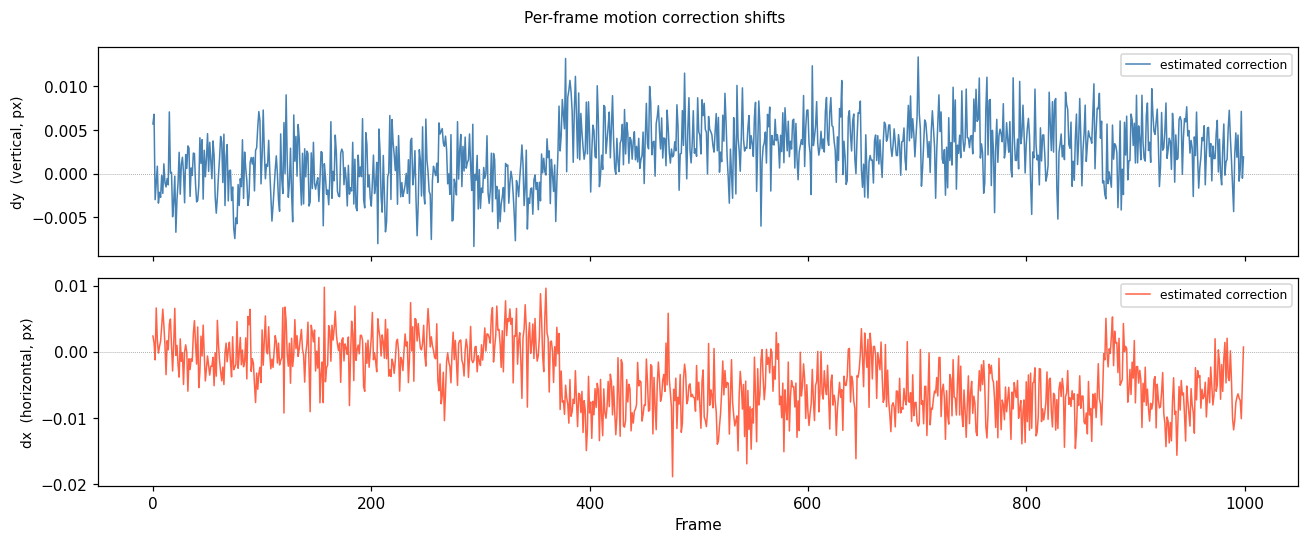

Max |dy|=0.01 px   Max |dx|=0.02 px


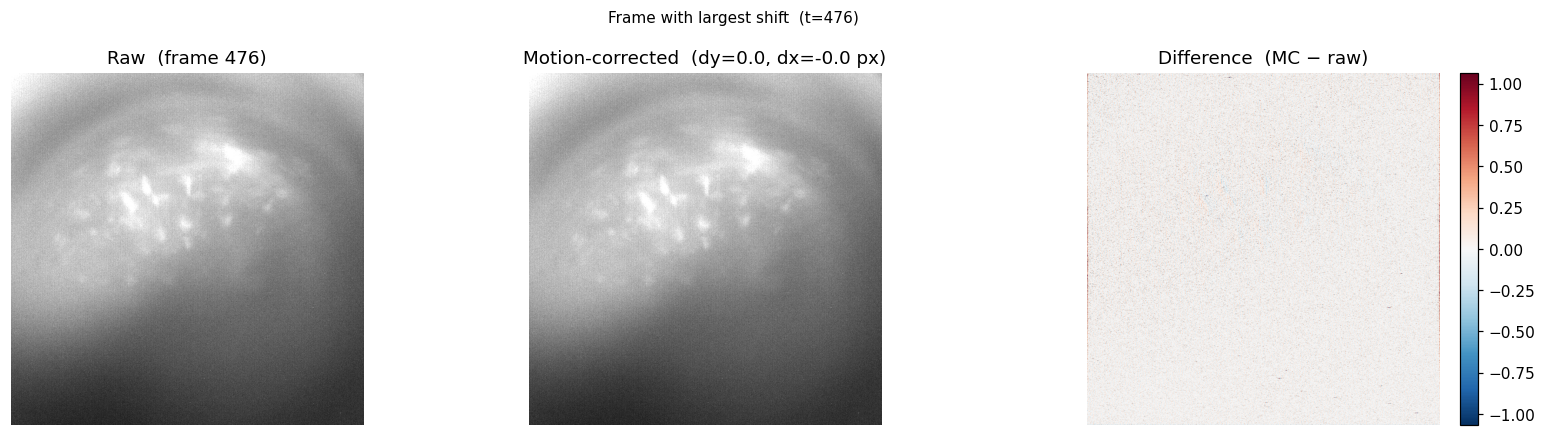

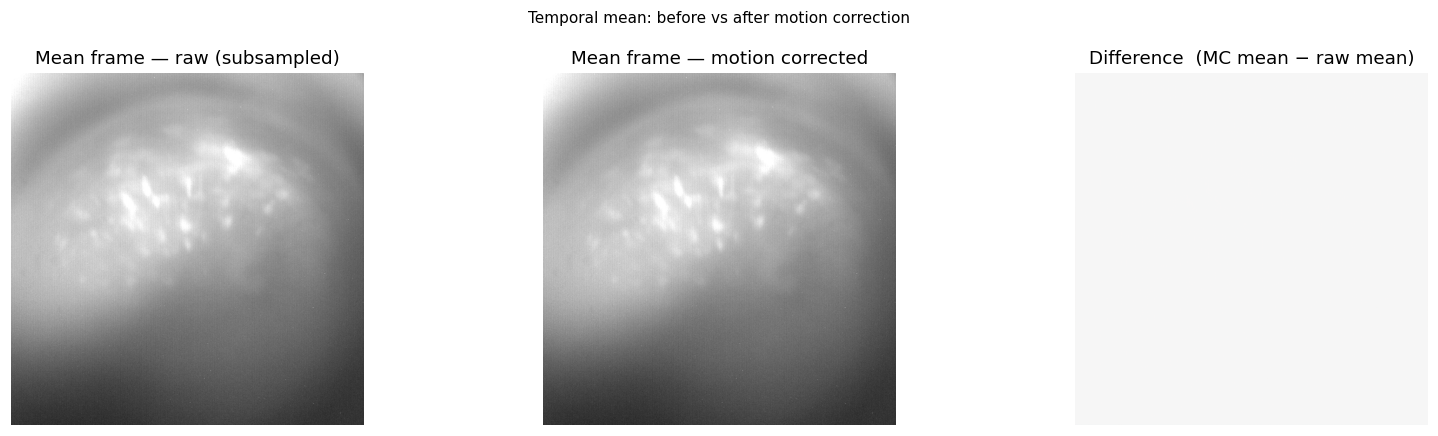

In [10]:
est = model.shifts   # (T, 2)  dy, dx per frame

# ── 1. Shift trajectory ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, dim, lbl, col in zip(axes, [0, 1],
                              ["dy  (vertical, px)", "dx  (horizontal, px)"],
                              ["steelblue", "tomato"]):
    if true_shifts is not None:
        ax.plot(true_shifts[:, dim], lw=1.5, ls="--", color="k", alpha=0.7,
                label="simulated drift (true)")
        ax.plot(-est[:, dim], lw=1.0, color=col,
                label="−correction  (should match drift)")
    else:
        ax.plot(est[:, dim], lw=1.0, color=col, label="estimated correction")
    ax.set_ylabel(lbl, fontsize=9)
    ax.legend(fontsize=8)
    ax.axhline(0, color="gray", lw=0.5, ls=":")
axes[-1].set_xlabel("Frame")
plt.suptitle("Per-frame motion correction shifts", fontsize=10)
plt.tight_layout()
plt.show()
print(f"Max |dy|={float(np.abs(est[:,0]).max()):.2f} px   "
      f"Max |dx|={float(np.abs(est[:,1]).max()):.2f} px")

# ── 2. Frame comparison at peak-shift time point ──────────────────────────────
# Load one frame from each zarr — decompresses only the relevant chunk.
peak_t    = int(np.argmax(np.linalg.norm(est, axis=1)))
raw_frame = np.asarray(z[peak_t], dtype=np.float32)
mc_frame  = np.asarray(mc_arr[peak_t], dtype=np.float32)
vmax_cmp  = float(np.percentile(raw_frame, 99.5))
diff      = mc_frame - raw_frame
dmax      = float(np.abs(diff).max()) + 1e-6

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(raw_frame, cmap="gray", vmin=0, vmax=vmax_cmp)
axes[0].set_title(f"Raw  (frame {peak_t})")
axes[0].axis("off")
axes[1].imshow(mc_frame, cmap="gray", vmin=0, vmax=vmax_cmp)
axes[1].set_title(
    f"Motion-corrected  (dy={est[peak_t,0]:.1f}, dx={est[peak_t,1]:.1f} px)")
axes[1].axis("off")
im = axes[2].imshow(diff, cmap="RdBu_r", vmin=-dmax, vmax=dmax)
axes[2].set_title("Difference  (MC − raw)")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.suptitle(f"Frame with largest shift  (t={peak_t})", fontsize=10)
plt.tight_layout()
plt.show()

# ── 3. Mean frame before vs after (subsampled — avoids loading full zarr) ────
# mean_img was computed in the parameter-estimation cell from the raw subsample.
stride_mc = max(1, T_mc // 1000)
t_mc_idx  = np.arange(0, T_mc, stride_mc)
mean_mc   = np.asarray(mc_arr[t_mc_idx], dtype=np.float32).mean(axis=0)
vmax_m    = float(np.percentile(mean_mc, 99.5))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(mean_img, cmap="gray", vmin=0, vmax=vmax_m)
axes[0].set_title("Mean frame — raw (subsampled)")
axes[0].axis("off")
axes[1].imshow(mean_mc, cmap="gray", vmin=0, vmax=vmax_m)
axes[1].set_title("Mean frame — motion corrected")
axes[1].axis("off")
axes[2].imshow(mean_mc - mean_img, cmap="RdBu_r",
               vmin=-vmax_m * 0.1, vmax=vmax_m * 0.1)
axes[2].set_title("Difference  (MC mean − raw mean)")
axes[2].axis("off")
plt.suptitle("Temporal mean: before vs after motion correction", fontsize=10)
plt.tight_layout()
plt.show()

## 2c. Export motion-corrected movie as AVI

Percentile-normalises `mc_arr` to uint8 and writes `demo_output/motion_corrected.avi`.
Uses cv2 (XVID codec) with imageio and tifffile as fallbacks.

In [11]:
import cv2

# Estimate lo/hi from a subsample — avoids loading the full zarr into RAM.
stride_pct  = max(1, T_mc // 2000)
sample_mc   = np.asarray(mc_arr[::stride_pct], dtype=np.float32)
lo, hi      = np.percentile(sample_mc, [1, 99.5])
del sample_mc

avi_path    = str(demo_out / "motion_corrected.avi")
fps         = 20
block_size  = 500   # frames per streaming block

try:
    fourcc = cv2.VideoWriter_fourcc(*"XVID")
    writer = cv2.VideoWriter(avi_path, fourcc, fps, (W_mc, H_mc), isColor=False)
    if not writer.isOpened():
        raise RuntimeError("cv2.VideoWriter failed to open")

    for start in range(0, T_mc, block_size):
        end   = min(start + block_size, T_mc)
        block = np.asarray(mc_arr[start:end], dtype=np.float32)
        block_u8 = ((block - lo) / (hi - lo + 1e-10) * 255).clip(0, 255).astype(np.uint8)
        for f in block_u8:
            writer.write(f)

    writer.release()
    print(f"Saved: {avi_path}")

except Exception as e:
    print(f"cv2 failed ({e}), trying imageio...")
    try:
        import imageio.v2 as iio2
        # Stream frame by frame so we never hold the full uint8 movie in RAM.
        with iio2.get_writer(avi_path, fps=fps, codec="libx264", macro_block_size=1) as vid_writer:
            for start in range(0, T_mc, block_size):
                end   = min(start + block_size, T_mc)
                block = np.asarray(mc_arr[start:end], dtype=np.float32)
                block_u8 = ((block - lo) / (hi - lo + 1e-10) * 255).clip(0, 255).astype(np.uint8)
                for f in block_u8:
                    vid_writer.append_data(f)
        print(f"Saved (imageio): {avi_path}")
    except Exception as e2:
        import tifffile
        tif_path = avi_path.replace(".avi", ".tif")
        # tifffile can write incrementally too, but here we accept loading all for TIFF
        frames_u8 = np.empty((T_mc, H_mc, W_mc), dtype=np.uint8)
        for start in range(0, T_mc, block_size):
            end  = min(start + block_size, T_mc)
            block = np.asarray(mc_arr[start:end], dtype=np.float32)
            frames_u8[start:end] = ((block - lo) / (hi - lo + 1e-10) * 255).clip(0, 255).astype(np.uint8)
        tifffile.imwrite(tif_path, frames_u8, photometric="minisblack")
        print(f"cv2+imageio both failed — saved as TIFF stack: {tif_path}  (open in ImageJ/napari)")

Saved: demo_output\motion_corrected.avi


## 3. CNMFe extraction

Runs the full extraction pipeline on the motion-corrected movie already held in `mc_arr`:
noise estimation → CORR/PNR seeding → greedy initialization → ring background →
iterative spatial/temporal refinement → merging.

`do_motion_correction=False` skips the correction step so `mc_arr` is used as-is.
The `model.shifts` estimated above are preserved on the model object.

In [ ]:
t0 = time.time()
model.fit(mc_arr, do_motion_correction=False, output_dir=demo_out)
print(f"\nExtraction done in {time.time() - t0:.1f} s  —  {model.A.shape[1]} neurons extracted")

## 3b. Comparison movie: MC | neuron overlay | neural reconstruction

Three panels rendered side-by-side into `demo_output/comparison.avi`:

| Panel | Content | How to read it |
|-------|---------|----------------|
| **Left** | Motion-corrected grayscale | Raw signal after alignment |
| **Centre** | MC + colored neuron overlay | Each neuron gets a distinct `tab20` color, brightness ∝ normalized `C + YrA` activity |
| **Right** | Neural reconstruction `A @ (C+YrA)[:, t]` | Model prediction — should light up at the same times and locations as the left panel |

In [ ]:
import matplotlib.cm as cm

Cproj  = (model.C + model.YrA).astype(np.float32)   # (K, T)
K_vid  = Cproj.shape[0]
H_vid, W_vid = model.dims

# Per-neuron distinct color (tab20 cycles every 20)
cmap_tab = cm.colormaps.get_cmap("tab20")
colors   = np.array([cmap_tab(k / max(K_vid, 1))[:3] for k in range(K_vid)], dtype=np.float32)

# Per-neuron normalise traces to [0, 1] so low-amplitude neurons still appear
Cp_min  = Cproj.min(axis=1, keepdims=True)
Cp_max  = Cproj.max(axis=1, keepdims=True)
Cproj_n = (Cproj - Cp_min) / (Cp_max - Cp_min + 1e-10)

# Max-normalise A columns so each footprint's peak = 1
A_arr   = np.asarray(model.A.todense(), dtype=np.float32)
col_max = A_arr.max(axis=0)
col_max[col_max == 0] = 1.0
A_norm  = A_arr / col_max[np.newaxis, :]

# mc_lo / mc_hi from the AVI export cell (lo, hi)
mc_lo, mc_hi = float(lo), float(hi)

comp_path  = str(demo_out / "comparison.avi")
T_vid      = Cproj.shape[1]
total_W    = W_vid * 3
fps_vid    = 20
block_size = 200   # frames per streaming block

try:
    fourcc_c    = cv2.VideoWriter_fourcc(*"XVID")
    comp_writer = cv2.VideoWriter(comp_path, fourcc_c, fps_vid, (total_W, H_vid), isColor=True)
    if not comp_writer.isOpened():
        raise RuntimeError("cv2.VideoWriter failed")
    use_cv2 = True
except Exception:
    use_cv2     = False
    comp_frames = []

print(f"Rendering {T_vid} frames — 3-panel comparison (streaming from zarr)...")
for blk_start in range(0, T_vid, block_size):
    blk_end  = min(blk_start + block_size, T_vid)
    mc_block = np.asarray(mc_arr[blk_start:blk_end], dtype=np.float32)

    for i, t in enumerate(range(blk_start, blk_end)):
        # Panel 1 — MC grayscale
        mc_f  = mc_block[i]
        p1_u8 = ((mc_f - mc_lo) / (mc_hi - mc_lo + 1e-10) * 255).clip(0, 255).astype(np.uint8)
        p1    = np.stack([p1_u8] * 3, axis=-1)

        # Panel 2 — colored neuron overlay
        act_t   = Cproj_n[:, t]
        overlay = A_norm @ (act_t[:, None] * colors)
        overlay = overlay.reshape(H_vid, W_vid, 3)
        alpha   = overlay.max(axis=2, keepdims=True).clip(0, 1)
        bg_f    = (p1_u8.astype(np.float32) / 255.0)[:, :, None]
        p2_f    = bg_f * (1.0 - alpha * 0.8) + overlay * alpha
        p2      = (np.clip(p2_f, 0, 1) * 255).astype(np.uint8)

        # Panel 3 — neural reconstruction (sparse matmul per frame)
        recon = np.asarray(model.A.dot(Cproj_n[:, t])).ravel().reshape(H_vid, W_vid)
        r_max = recon.max() + 1e-10
        p3_u8 = (recon / r_max * 255).clip(0, 255).astype(np.uint8)
        p3    = np.stack([p3_u8] * 3, axis=-1)

        for panel, label in [(p1, "MC"), (p2, "Overlay"), (p3, "Reconstruction")]:
            cv2.putText(panel, label, (4, 18), cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (255, 255, 255), 1, cv2.LINE_AA)

        frame_rgb = np.concatenate([p1, p2, p3], axis=1)
        frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)

        if use_cv2:
            comp_writer.write(frame_bgr)
        else:
            comp_frames.append(frame_bgr)

if use_cv2:
    comp_writer.release()
    print(f"Saved: {comp_path}")
else:
    try:
        import imageio.v2 as iio2
        iio2.mimwrite(comp_path, [cv2.cvtColor(f, cv2.COLOR_BGR2RGB) for f in comp_frames],
                      fps=fps_vid, codec="libx264", macro_block_size=1)
        print(f"Saved (imageio): {comp_path}")
    except Exception:
        import tifffile
        tif_path = comp_path.replace(".avi", ".tif")
        tifffile.imwrite(tif_path, np.stack(comp_frames), photometric="rgb")
        print(f"Saved as TIFF stack: {tif_path}")

## 4. Extracted spatial footprints

In [ ]:
import scipy.sparse as sp

A_est = np.asarray(model.A.todense())   # (H*W, K_est)
K_est = model.A.shape[1]

if has_ground_truth:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(A_true.max(axis=1).reshape(H, W), cmap="hot")
    axes[0].set_title(f"True footprints (n={K_true})")
    axes[0].axis("off")

    axes[1].imshow(A_est.max(axis=1).reshape(H, W), cmap="hot")
    axes[1].set_title(f"Extracted footprints (n={K_est})")
    axes[1].axis("off")

    ov = np.zeros((H, W, 3), dtype=np.float32)
    ov[:, :, 0] = A_true.max(axis=1).reshape(H, W)
    ov[:, :, 1] = A_est.max(axis=1).reshape(H, W)
    ov = (ov - ov.min()) / (ov.max() - ov.min() + 1e-8)
    axes[2].imshow(ov)
    axes[2].set_title("Overlay: true = red   extracted = green")
    axes[2].axis("off")

    plt.suptitle("Spatial footprints — max projection", fontsize=10)
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # mean_mc was computed in the quality-check cell from a subsampled zarr slice
    axes[0].imshow(mean_mc, cmap="gray")
    axes[0].set_title("Mean MC frame")
    axes[0].axis("off")

    axes[1].imshow(A_est.max(axis=1).reshape(H, W), cmap="hot")
    axes[1].set_title(f"Extracted footprints (n={K_est})")
    axes[1].axis("off")

    plt.suptitle("Spatial footprints — max projection", fontsize=10)

plt.tight_layout()
plt.show()
print(f"Extracted {K_est} neurons")

## 5. Recovery metrics (synthetic data only)

When running on synthetic demo movies, matches each true neuron to its best extracted
counterpart by spatial correlation, then scores temporal recovery using `C + YrA`
(the noisy projected trace, which preserves the data's actual shape better than the
OASIS-deconvolved `C` alone).

For real recordings this cell prints a summary count instead.

In [ ]:
def pearson(a, b):
    a = a - a.mean(); b = b - b.mean()
    d = float(np.sqrt(np.sum(a ** 2) * np.sum(b ** 2)))
    return float(np.dot(a, b) / d) if d > 0 else 0.0

if has_ground_truth:
    # Match true → extracted by spatial correlation
    matches = []
    for k_true in range(K_true):
        a_t   = A_true[:, k_true]
        corrs = [pearson(a_t, A_est[:, k]) for k in range(K_est)]
        best  = int(np.argmax(corrs))
        matches.append((k_true, best, float(corrs[best])))

    rs_A  = np.array([m[2] for m in matches])
    Cproj = model.C + model.YrA   # noisy projected trace (shape-faithful)
    rs_T  = np.array([pearson(Cproj[ke], C_true[kt]) for kt, ke, _ in matches])
    fp    = K_est - int((rs_A > 0.7).sum())

    print(f"Extracted          : {K_est}  (true={K_true},  FP candidates={fp})")
    print(f"Recovered (r>0.7)  : {int((rs_A > 0.7).sum())}/{K_true}")
    print(f"Mean spatial r     : {rs_A.mean():.3f}  (min {rs_A.min():.3f})")
    print(f"Mean temporal r    : {rs_T.mean():.3f}  (min {rs_T.min():.3f})")
    print()
    print(f"{'neuron':>6}  {'spatial r':>9}  {'temporal r':>10}")
    for kt, ke, rs_a in matches:
        print(f"{kt:6d}  {rs_a:9.3f}  {rs_T[kt]:10.3f}")
else:
    print("No ground truth — skipping recovery metrics.")
    print(f"Extracted {K_est} neurons.")

## 6. Temporal traces — extracted vs ground truth

In [ ]:
def norm01(x):
    lo_n, hi_n = float(x.min()), float(x.max())
    return (x - lo_n) / (hi_n - lo_n + 1e-10)

Cproj = model.C + model.YrA   # noisy projected trace (shape-faithful)

if has_ground_truth:
    n_show = min(6, K_true)
    fig, axes = plt.subplots(n_show, 1, figsize=(11, 1.6 * n_show), sharex=True)
    if n_show == 1:
        axes = [axes]
    for ax, (kt, ke, rs_a) in zip(axes, matches[:n_show]):
        ax.plot(norm01(C_true[kt]), lw=1.2, color="black", ls="--", alpha=0.6,
                label="truth")
        ax.plot(norm01(Cproj[ke]), lw=0.9, color="steelblue",
                label=f"C+YrA  r={pearson(Cproj[ke], C_true[kt]):.2f}")
        ax.set_ylabel(f"n{kt}", fontsize=8)
        ax.legend(loc="upper right", fontsize=7)
    axes[-1].set_xlabel("Frame")
    plt.suptitle("Temporal recovery: C + YrA vs ground truth (normalised)", fontsize=10)
else:
    # Real data: show first 6 extracted traces (C+YrA = noisy projected, C = deconvolved)
    n_show = min(6, K_est)
    fig, axes = plt.subplots(n_show, 1, figsize=(11, 1.6 * n_show), sharex=True)
    if n_show == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.plot(norm01(Cproj[i]), lw=0.9, color="steelblue", label="C + YrA (noisy)")
        ax.plot(norm01(model.C[i]), lw=1.0, color="tomato", alpha=0.8, label="C (deconvolved)")
        ax.set_ylabel(f"n{i}", fontsize=8)
        ax.legend(loc="upper right", fontsize=7)
    axes[-1].set_xlabel("Frame")
    plt.suptitle(f"Temporal traces — first {n_show} neurons (normalised)", fontsize=10)

plt.tight_layout()
plt.show()